# 🎓 College Feedback Intelligence System

## NLP-Based Student Feedback Analysis

### Problem Statement

Colleges receive a large amount of student feedback through surveys
and forms. Manually analyzing this feedback is time-consuming.

This project uses Natural Language Processing (NLP) and Machine Learning
to automatically analyze student feedback.

### Objectives

1. Collect and prepare student feedback data.
2. Perform text preprocessing.
3. Analyze the sentiment of feedback.
4. Identify the major college-related aspects discussed.
5. Convert text into numerical features using TF-IDF.
6. Train a Machine Learning model for sentiment classification.
7. Evaluate the performance of the model.
8. Visualize useful insights from student feedback.

### Technologies Used

- Python
- Pandas
- NumPy
- NLTK
- Scikit-learn
- Matplotlib
- Seaborn

### NLP Techniques

- Text preprocessing
- Tokenization
- Stopword removal
- TF-IDF Vectorization
- Sentiment Classification
- Aspect-based analysis

In [2]:
import pandas as pd
import numpy as np
import random
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
nltk.download('punkt')
nltk.download('stopwords')

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK resources downloaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
random.seed(42)

feedback_data = {

    "Faculty": {
        "Positive": [
            "The faculty is very helpful and supportive",
            "The professor explains concepts clearly",
            "Teachers are knowledgeable and approachable",
            "The faculty members are excellent",
            "The teachers are very supportive",
            "Faculty members clear doubts properly"
        ],

        "Negative": [
            "The faculty does not explain concepts properly",
            "Some teachers are not supportive",
            "The professor does not clear doubts",
            "The teaching staff needs improvement",
            "Teachers do not pay attention to students",
            "Faculty members are difficult to approach"
        ],

        "Neutral": [
            "The faculty is okay",
            "The teachers are satisfactory",
            "Faculty support is average",
            "The faculty experience is normal",
            "Teachers are neither good nor bad"
        ]
    },

    "Teaching": {
        "Positive": [
            "The teaching quality is excellent",
            "Classes are interactive and informative",
            "The concepts are explained clearly",
            "The teaching methodology is effective",
            "The lectures are interesting",
            "The teaching style is easy to understand"
        ],

        "Negative": [
            "The teaching quality needs improvement",
            "Classes are often boring",
            "The concepts are not explained clearly",
            "The teaching method is difficult to understand",
            "Lectures are not interesting",
            "The teaching pace is too fast"
        ],

        "Neutral": [
            "The teaching quality is average",
            "Classes are okay",
            "The teaching method is satisfactory",
            "The lectures are normal"
        ]
    },

    "Laboratory": {
        "Positive": [
            "The laboratory has good equipment",
            "The lab facilities are excellent",
            "The computers in the lab work well",
            "The laboratory is well maintained",
            "The lab has modern equipment"
        ],

        "Negative": [
            "The laboratory computers are very slow",
            "The lab equipment is outdated",
            "Many computers in the lab do not work",
            "The laboratory needs better equipment",
            "The lab facilities are poor"
        ],

        "Neutral": [
            "The laboratory facilities are average",
            "The lab is okay",
            "Laboratory equipment is satisfactory"
        ]
    },

    "WiFi": {
        "Positive": [
            "The campus WiFi works very well",
            "Internet speed is good on campus",
            "The WiFi connection is stable",
            "The internet facility is reliable",
            "The campus internet is fast"
        ],

        "Negative": [
            "The campus WiFi is very slow",
            "Internet connectivity is poor",
            "The WiFi disconnects frequently",
            "The internet speed is extremely slow",
            "The campus internet does not work properly"
        ],

        "Neutral": [
            "The WiFi speed is average",
            "Internet connectivity is okay",
            "The campus internet is satisfactory"
        ]
    },

    "Library": {
        "Positive": [
            "The library has a good collection of books",
            "The library is quiet and comfortable",
            "The library facilities are excellent",
            "There are enough useful books",
            "The library environment is good"
        ],

        "Negative": [
            "The library does not have enough books",
            "The library needs better facilities",
            "Many required books are unavailable",
            "The library needs improvement",
            "The library is not properly maintained"
        ],

        "Neutral": [
            "The library is average",
            "The library facilities are satisfactory",
            "The library collection is okay"
        ]
    },

    "Hostel": {
        "Positive": [
            "The hostel rooms are clean and comfortable",
            "Hostel facilities are good",
            "The hostel is well maintained",
            "The hostel environment is comfortable"
        ],

        "Negative": [
            "The hostel rooms are not clean",
            "Hostel maintenance is poor",
            "The hostel facilities need improvement",
            "The rooms are uncomfortable"
        ],

        "Neutral": [
            "The hostel facilities are average",
            "The hostel is okay",
            "Hostel rooms are satisfactory"
        ]
    },

    "Canteen": {
        "Positive": [
            "The canteen food is tasty",
            "The canteen has good food options",
            "Food quality in the canteen is good",
            "The canteen is clean and hygienic"
        ],

        "Negative": [
            "The canteen food quality is poor",
            "The food is often not fresh",
            "The canteen is not clean",
            "The canteen service is slow"
        ],

        "Neutral": [
            "The canteen food is average",
            "The canteen is okay",
            "Food quality is satisfactory"
        ]
    },

    "Placement": {
        "Positive": [
            "The placement cell provides good opportunities",
            "The college provides excellent placement support",
            "Many companies visit the campus",
            "The placement training is useful"
        ],

        "Negative": [
            "The college provides limited placement opportunities",
            "Placement training needs improvement",
            "Very few companies visit the campus",
            "The placement support is not sufficient"
        ],

        "Neutral": [
            "Placement opportunities are average",
            "The placement support is satisfactory",
            "Some placement opportunities are available"
        ]
    },

    "Infrastructure": {
        "Positive": [
            "The campus infrastructure is excellent",
            "The classrooms are spacious and clean",
            "The college buildings are well maintained",
            "The campus facilities are very good"
        ],

        "Negative": [
            "The campus infrastructure needs improvement",
            "Some classrooms are poorly maintained",
            "The campus facilities are outdated",
            "There are not enough facilities"
        ],

        "Neutral": [
            "The infrastructure is average",
            "Campus facilities are satisfactory",
            "The infrastructure is okay"
        ]
    },

    "Course": {
        "Positive": [
            "The course curriculum is well designed",
            "The subjects are useful and relevant",
            "The course content is interesting",
            "The curriculum covers important concepts"
        ],

        "Negative": [
            "The course curriculum is outdated",
            "Some subjects are not useful",
            "The course content needs improvement",
            "The curriculum is too difficult"
        ],

        "Neutral": [
            "The course curriculum is average",
            "The course structure is satisfactory",
            "The subjects are okay"
        ]
    },

    "Examination": {
        "Positive": [
            "The examination process is well organized",
            "The exam schedule is convenient",
            "The examination system is fair",
            "The exams test our understanding properly"
        ],

        "Negative": [
            "The examination schedule is inconvenient",
            "The exam process is stressful",
            "The examination system needs improvement",
            "The examination process is not well organized"
        ],

        "Neutral": [
            "The examination process is average",
            "The exam system is satisfactory",
            "The examination process is okay"
        ]
    }
}

print("Feedback templates created successfully!")

Feedback templates created successfully!


In [5]:
departments = [
    "CSE",
    "ECE",
    "Mechanical",
    "Civil",
    "BBA"
]

semesters = [1, 2, 3, 4, 5, 6, 7, 8]

rows = []

for i in range(600):

    aspect = random.choice(list(feedback_data.keys()))

    sentiment = random.choices(
        ["Positive", "Negative", "Neutral"],
        weights=[50, 30, 20]
    )[0]

    feedback = random.choice(
        feedback_data[aspect][sentiment]
    )

    department = random.choice(departments)

    semester = random.choice(semesters)

    rows.append([
        i + 1,
        department,
        semester,
        feedback,
        sentiment,
        aspect
    ])


df = pd.DataFrame(
    rows,
    columns=[
        "id",
        "department",
        "semester",
        "feedback",
        "sentiment",
        "aspect"
    ]
)

print("Dataset created successfully!")
print("Total records:", len(df))

df.head()

Dataset created successfully!
Total records: 600


,id,department,semester,feedback,sentiment,aspect
0,1,ECE,4,The examination system is fair,Positive,Examination
1,2,CSE,7,The lab facilities are poor,Negative,Laboratory
2,3,ECE,1,The professor explains concepts clearly,Positive,Faculty
3,4,ECE,8,The campus facilities are very good,Positive,Infrastructure
4,5,ECE,7,The course curriculum is well designed,Positive,Course


In [6]:
df.to_csv(
    "college_feedback.csv",
    index=False
)

print("Dataset saved as college_feedback.csv")

Dataset saved as college_feedback.csv


In [7]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nAspect Distribution:")
print(df["aspect"].value_counts())

Dataset Shape: (600, 6)

Column Names:
['id', 'department', 'semester', 'feedback', 'sentiment', 'aspect']

Missing Values:
id            0
department    0
semester      0
feedback      0
sentiment     0
aspect        0
dtype: int64

Sentiment Distribution:
sentiment
Positive    293
Negative    186
Neutral     121
Name: count, dtype: int64

Aspect Distribution:
aspect
Laboratory        68
Examination       62
Placement         61
Course            58
Library           55
Canteen           54
Teaching          54
Hostel            53
WiFi              48
Infrastructure    45
Faculty           42
Name: count, dtype: int64


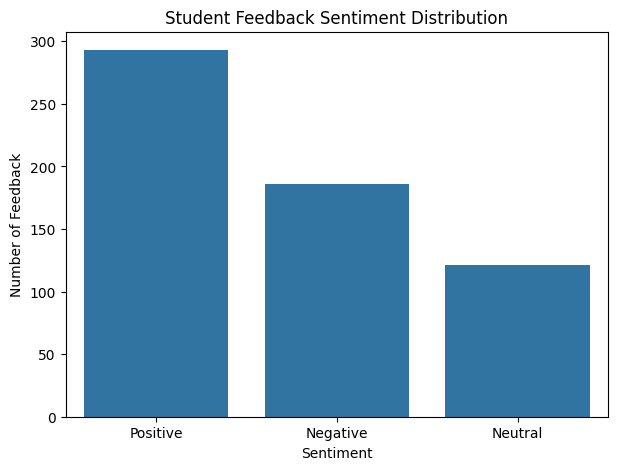

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Student Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback")

plt.show()

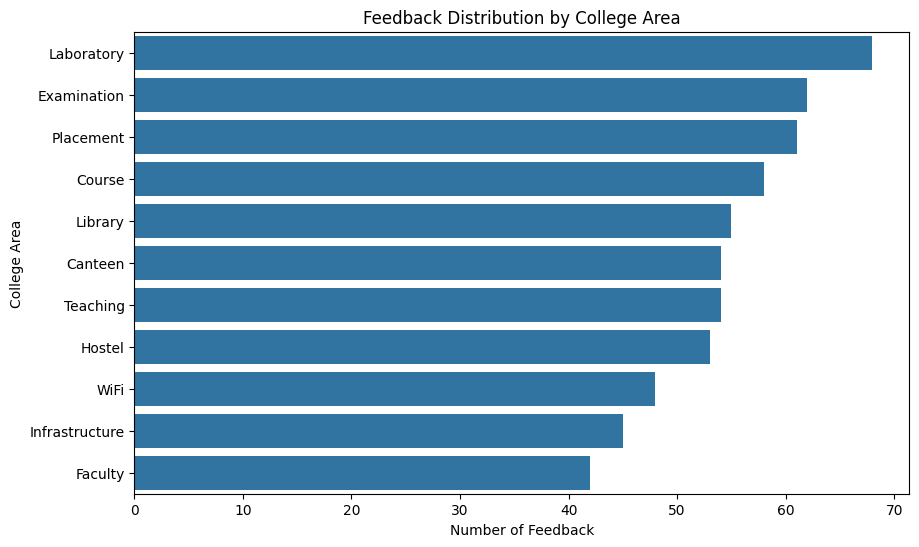

In [9]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="aspect",
    order=df["aspect"].value_counts().index
)

plt.title("Feedback Distribution by College Area")
plt.xlabel("Number of Feedback")
plt.ylabel("College Area")

plt.show()

In [10]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK resources downloaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join tokens back
    return " ".join(tokens)


df["clean_feedback"] = df["feedback"].apply(preprocess_text)

df[["feedback", "clean_feedback"]].head(10)

,feedback,clean_feedback
0,The examination system is fair,examination system fair
1,The lab facilities are poor,lab facilities poor
2,The professor explains concepts clearly,professor explains concepts clearly
3,The campus facilities are very good,campus facilities good
4,The course curriculum is well designed,course curriculum well designed
5,Hostel facilities are good,hostel facilities good
6,The concepts are explained clearly,concepts explained clearly
7,Teachers do not pay attention to students,teachers pay attention students
8,The teaching pace is too fast,teaching pace fast
9,The course curriculum is well designed,course curriculum well designed


In [12]:
for i in range(5):

    print("Original:")
    print(df["feedback"].iloc[i])

    print("\nAfter preprocessing:")
    print(df["clean_feedback"].iloc[i])

    print("-" * 60)

Original:
The examination system is fair

After preprocessing:
examination system fair
------------------------------------------------------------
Original:
The lab facilities are poor

After preprocessing:
lab facilities poor
------------------------------------------------------------
Original:
The professor explains concepts clearly

After preprocessing:
professor explains concepts clearly
------------------------------------------------------------
Original:
The campus facilities are very good

After preprocessing:
campus facilities good
------------------------------------------------------------
Original:
The course curriculum is well designed

After preprocessing:
course curriculum well designed
------------------------------------------------------------


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(
    df["clean_feedback"]
)

y = df["sentiment"]

print("TF-IDF conversion completed!")

print("Number of documents:", X.shape[0])
print("Number of features:", X.shape[1])

TF-IDF conversion completed!
Number of documents: 600
Number of features: 368


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 480
Testing samples: 120


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Model Accuracy: 96.67 %

Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      0.89      0.94        37
     Neutral       1.00      1.00      1.00        24
    Positive       0.94      1.00      0.97        59

    accuracy                           0.97       120
   macro avg       0.98      0.96      0.97       120
weighted avg       0.97      0.97      0.97       120



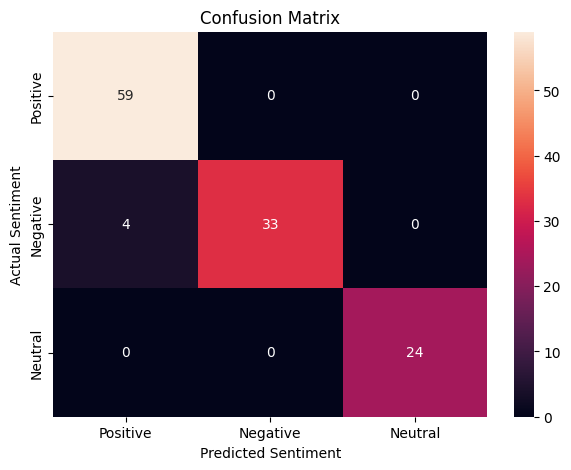

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Positive", "Negative", "Neutral"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Positive", "Negative", "Neutral"],
    yticklabels=["Positive", "Negative", "Neutral"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [18]:
aspect_sentiment = pd.crosstab(
    df["aspect"],
    df["sentiment"]
)

aspect_sentiment

sentiment,Negative,Neutral,Positive
aspect,,,
Canteen,20,6,28
Course,21,8,29
Examination,20,15,27
Faculty,11,7,24
Hostel,19,12,22
Infrastructure,10,10,25
Laboratory,23,16,29
Library,15,12,28
Placement,21,15,25


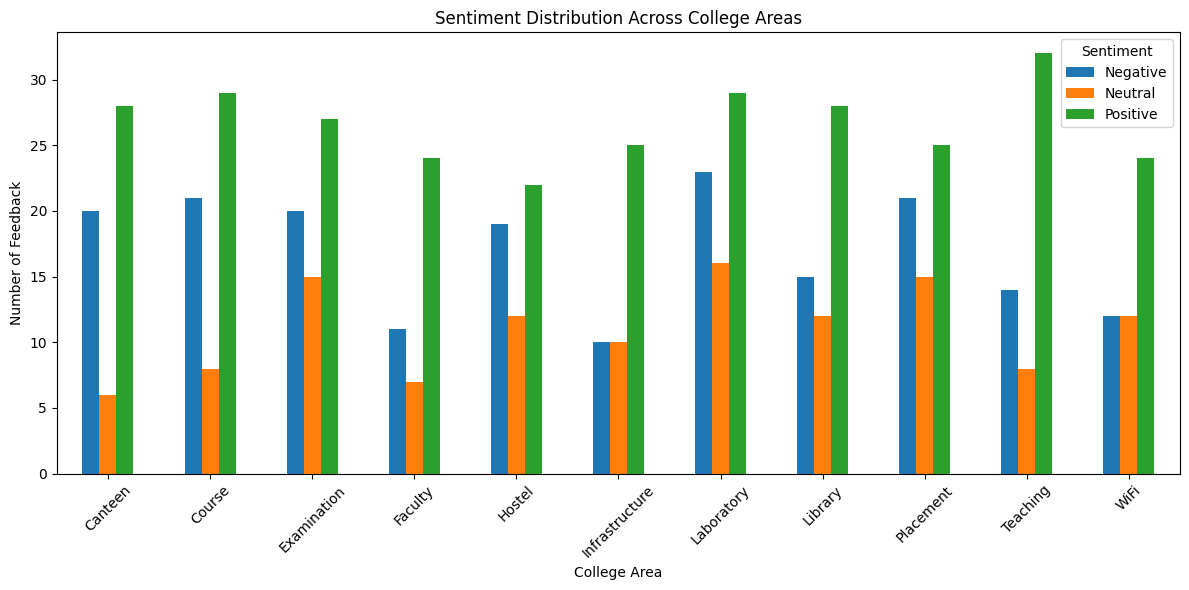

In [19]:
aspect_sentiment.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sentiment Distribution Across College Areas")
plt.xlabel("College Area")
plt.ylabel("Number of Feedback")
plt.xticks(rotation=45)

plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [20]:
negative_feedback = (
    df[df["sentiment"] == "Negative"]
    ["aspect"]
    .value_counts()
)

print("Negative Feedback by College Area:")
print(negative_feedback)

Negative Feedback by College Area:
aspect
Laboratory        23
Placement         21
Course            21
Examination       20
Canteen           20
Hostel            19
Library           15
Teaching          14
WiFi              12
Faculty           11
Infrastructure    10
Name: count, dtype: int64


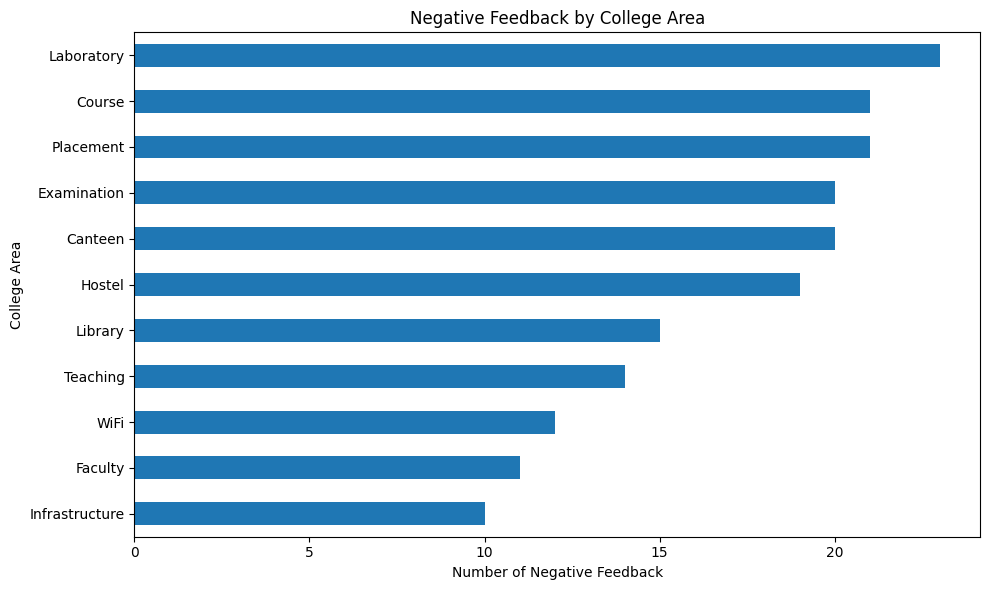

In [21]:
plt.figure(figsize=(10, 6))

negative_feedback.sort_values().plot(
    kind="barh"
)

plt.title("Negative Feedback by College Area")
plt.xlabel("Number of Negative Feedback")
plt.ylabel("College Area")

plt.tight_layout()
plt.show()

In [22]:
positive_feedback = (
    df[df["sentiment"] == "Positive"]
    ["aspect"]
    .value_counts()
)

print("Positive Feedback by College Area:")
print(positive_feedback)

Positive Feedback by College Area:
aspect
Teaching          32
Course            29
Laboratory        29
Canteen           28
Library           28
Examination       27
Infrastructure    25
Placement         25
Faculty           24
WiFi              24
Hostel            22
Name: count, dtype: int64


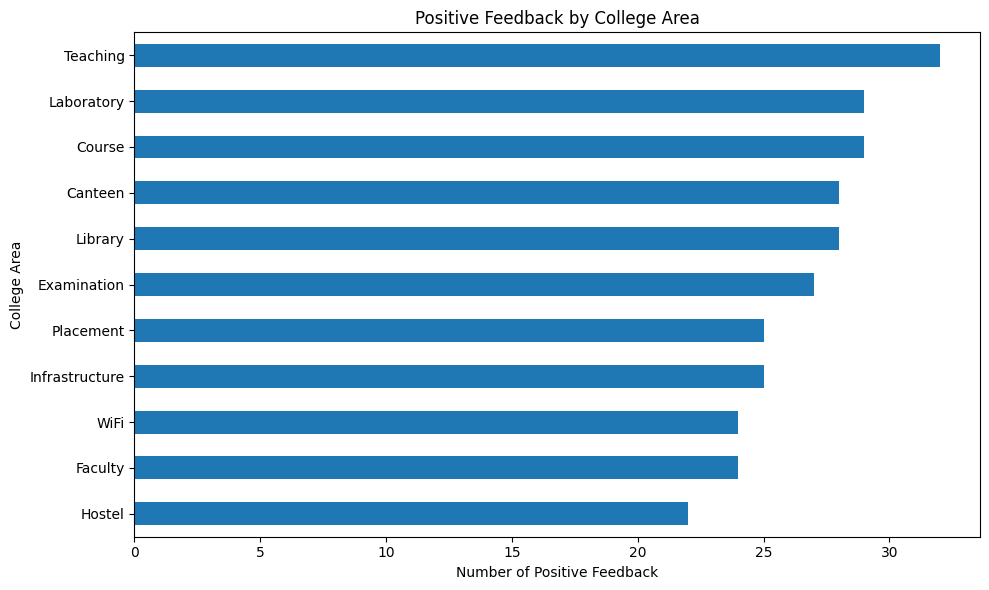

In [23]:
plt.figure(figsize=(10, 6))

positive_feedback.sort_values().plot(
    kind="barh"
)

plt.title("Positive Feedback by College Area")
plt.xlabel("Number of Positive Feedback")
plt.ylabel("College Area")

plt.tight_layout()
plt.show()

In [24]:
def predict_feedback(feedback):

    # Preprocess the new feedback
    cleaned = preprocess_text(feedback)

    # Convert text to TF-IDF
    vector = tfidf.transform([cleaned])

    # Predict sentiment
    prediction = model.predict(vector)[0]

    return prediction

In [25]:
new_feedback = "The campus WiFi is extremely slow"

result = predict_feedback(new_feedback)

print("Feedback:", new_feedback)
print("Predicted Sentiment:", result)

Feedback: The campus WiFi is extremely slow
Predicted Sentiment: Negative


In [26]:
aspect_keywords = {
    "Faculty": [
        "faculty", "professor", "teacher"
    ],

    "Teaching": [
        "teaching", "lecture", "explain", "concept"
    ],

    "Laboratory": [
        "lab", "laboratory", "computer"
    ],

    "WiFi": [
        "wifi", "internet", "network"
    ],

    "Library": [
        "library", "books"
    ],

    "Hostel": [
        "hostel", "room", "warden"
    ],

    "Canteen": [
        "canteen", "food", "cafeteria"
    ],

    "Placement": [
        "placement", "job", "company", "recruitment"
    ],

    "Infrastructure": [
        "building", "classroom", "infrastructure"
    ],

    "Course": [
        "course", "syllabus", "subject"
    ],

    "Examination": [
        "exam", "examination", "test", "question"
    ]
}

In [27]:
def detect_aspect(feedback):

    text = feedback.lower()

    for aspect, keywords in aspect_keywords.items():

        for keyword in keywords:

            if keyword in text:
                return aspect

    return "General"

In [28]:
test_feedback = "The campus WiFi is extremely slow"

print("Detected Aspect:", detect_aspect(test_feedback))

Detected Aspect: WiFi


In [29]:
def analyze_feedback(feedback):

    sentiment = predict_feedback(feedback)
    aspect = detect_aspect(feedback)

    print("Feedback:", feedback)
    print("Detected Aspect:", aspect)
    print("Predicted Sentiment:", sentiment)

In [30]:
analyze_feedback(
    "The faculty explains concepts very clearly"
)

print("\n" + "-" * 60 + "\n")

analyze_feedback(
    "The hostel rooms are not clean"
)

print("\n" + "-" * 60 + "\n")

analyze_feedback(
    "The library has a good collection of books"
)

print("\n" + "-" * 60 + "\n")

analyze_feedback(
    "The campus WiFi is extremely slow"
)

Feedback: The faculty explains concepts very clearly
Detected Aspect: Faculty
Predicted Sentiment: Positive

------------------------------------------------------------

Feedback: The hostel rooms are not clean
Detected Aspect: Hostel
Predicted Sentiment: Negative

------------------------------------------------------------

Feedback: The library has a good collection of books
Detected Aspect: Library
Predicted Sentiment: Positive

------------------------------------------------------------

Feedback: The campus WiFi is extremely slow
Detected Aspect: WiFi
Predicted Sentiment: Negative


In [31]:
user_feedback = input("Enter your college feedback: ")

analyze_feedback(user_feedback)

Enter your college feedback: Library is good
Feedback: Library is good
Detected Aspect: Library
Predicted Sentiment: Positive


# 📊 Project Results and Insights

This section summarizes the major findings obtained from the student feedback dataset.

In [32]:
print("===== COLLEGE FEEDBACK SUMMARY =====")

print("Total Feedback:", len(df))

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nCollege Areas Covered:")
print(df["aspect"].nunique())

print("\nMost Discussed College Areas:")
print(df["aspect"].value_counts().head(5))

===== COLLEGE FEEDBACK SUMMARY =====
Total Feedback: 600

Sentiment Distribution:
sentiment
Positive    293
Negative    186
Neutral     121
Name: count, dtype: int64

College Areas Covered:
11

Most Discussed College Areas:
aspect
Laboratory     68
Examination    62
Placement      61
Course         58
Library        55
Name: count, dtype: int64


In [33]:
sentiment_percentage = (
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Sentiment Percentage:")
print(sentiment_percentage)

Sentiment Percentage:
sentiment
Positive    48.83
Negative    31.00
Neutral     20.17
Name: proportion, dtype: float64


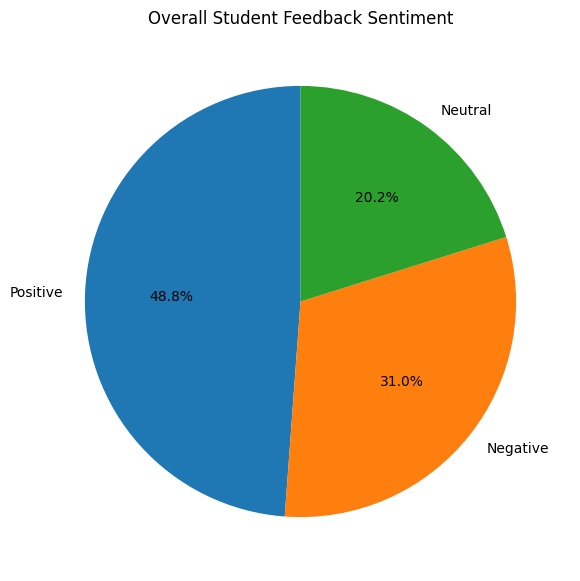

In [34]:
plt.figure(figsize=(7, 7))

df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Student Feedback Sentiment")
plt.ylabel("")

plt.show()

In [35]:
department_sentiment = pd.crosstab(
    df["department"],
    df["sentiment"]
)

department_sentiment

sentiment,Negative,Neutral,Positive
department,,,
BBA,40,15,62
CSE,36,34,46
Civil,43,20,53
ECE,34,26,58
Mechanical,33,26,74


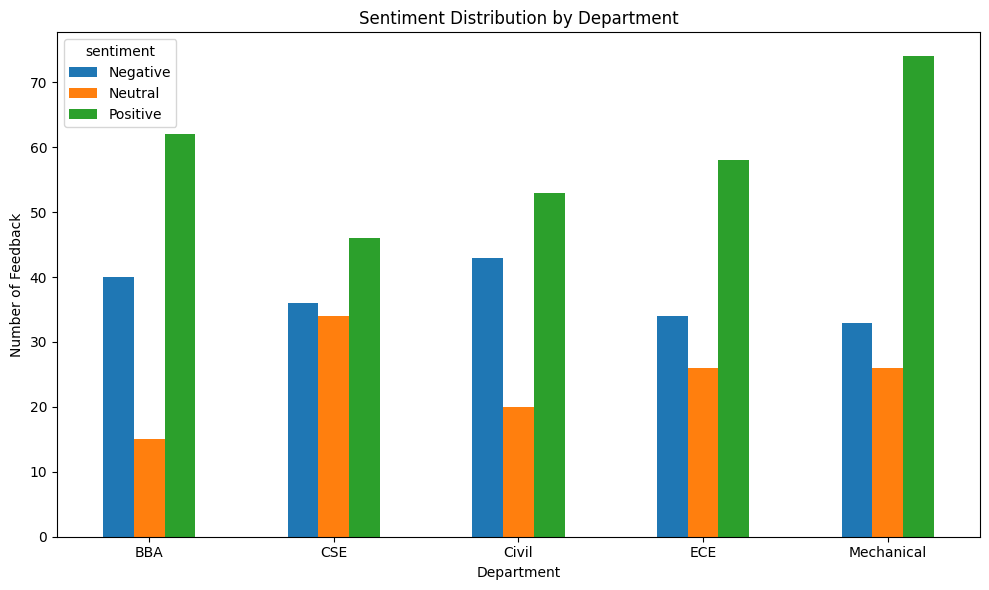

In [36]:
department_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Feedback")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [37]:
semester_sentiment = pd.crosstab(
    df["semester"],
    df["sentiment"]
)

semester_sentiment

sentiment,Negative,Neutral,Positive
semester,,,
1,21,18,37
2,32,10,39
3,26,11,31
4,19,16,39
5,19,16,34
6,27,16,30
7,22,13,35
8,20,21,48


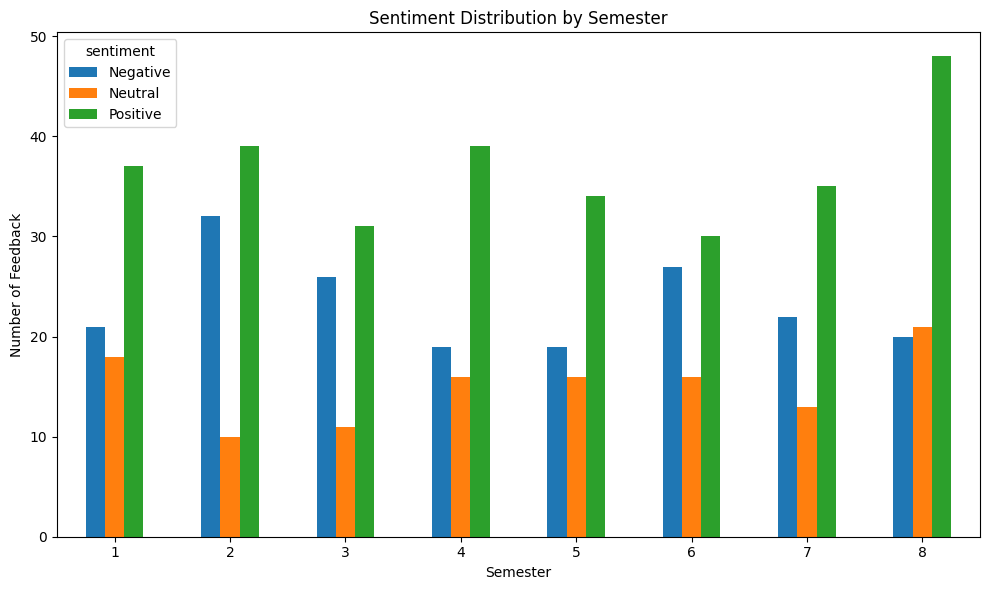

In [38]:
semester_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Semester")
plt.xlabel("Semester")
plt.ylabel("Number of Feedback")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

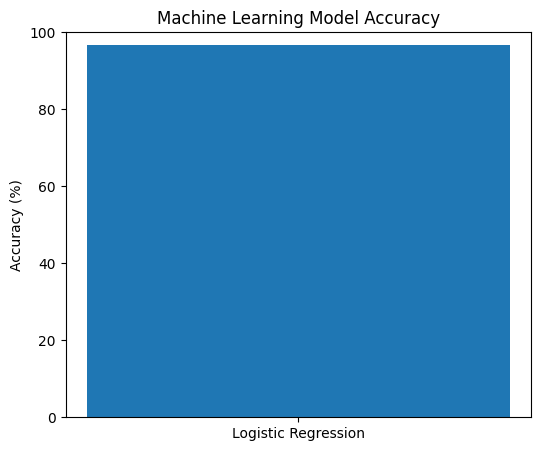

Logistic Regression Accuracy: 96.67 %


In [39]:
model_accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.bar(
    ["Logistic Regression"],
    [model_accuracy * 100]
)

plt.ylabel("Accuracy (%)")
plt.title("Machine Learning Model Accuracy")
plt.ylim(0, 100)

plt.show()

print(
    "Logistic Regression Accuracy:",
    round(model_accuracy * 100, 2),
    "%"
)

In [40]:
from google.colab import files

uploaded = files.upload()

Saving college_feedback_sample.csv to college_feedback_sample.csv


In [41]:
import pandas as pd

file_name = list(uploaded.keys())[0]

uploaded_df = pd.read_csv(file_name)

print("File loaded successfully!")
print("Number of reviews:", len(uploaded_df))

uploaded_df.head()

File loaded successfully!
Number of reviews: 30


,feedback
0,The faculty explains concepts very clearly and...
1,The campus WiFi is extremely slow and disconne...
2,The library has an excellent collection of books
3,The hostel rooms are not clean and need better...
4,The placement department provides good career ...


In [42]:
possible_columns = [
    "feedback",
    "Feedback",
    "review",
    "Review",
    "comment",
    "Comment",
    "comments",
    "Comments"
]

feedback_column = None

for column in possible_columns:
    if column in uploaded_df.columns:
        feedback_column = column
        break

if feedback_column is None:
    print("Available columns:")
    print(uploaded_df.columns.tolist())
    raise ValueError(
        "Could not find a feedback/review column."
    )

print("Feedback column detected:", feedback_column)

Feedback column detected: feedback


In [43]:
uploaded_df["clean_feedback"] = (
    uploaded_df[feedback_column]
    .astype(str)
    .apply(preprocess_text)
)

# Convert feedback to TF-IDF
uploaded_vectors = tfidf.transform(
    uploaded_df["clean_feedback"]
)

# Predict sentiment
uploaded_df["predicted_sentiment"] = (
    model.predict(uploaded_vectors)
)

# Detect aspect
uploaded_df["detected_aspect"] = (
    uploaded_df[feedback_column]
    .astype(str)
    .apply(detect_aspect)
)

print("All feedback analyzed successfully!")

uploaded_df.head(10)

All feedback analyzed successfully!


,feedback,clean_feedback,predicted_sentiment,detected_aspect
0,The faculty explains concepts very clearly and...,faculty explains concepts clearly supportive,Positive,Faculty
1,The campus WiFi is extremely slow and disconne...,campus wifi extremely slow disconnects frequently,Negative,WiFi
2,The library has an excellent collection of books,library excellent collection books,Positive,Library
3,The hostel rooms are not clean and need better...,hostel rooms clean need better maintenance,Negative,Hostel
4,The placement department provides good career ...,placement department provides good career oppo...,Positive,Placement
5,The canteen food is tasty and reasonably priced,canteen food tasty reasonably priced,Positive,Canteen
6,The laboratory computers are very slow,laboratory computers slow,Negative,Laboratory
7,The classroom infrastructure is good and well ...,classroom infrastructure good well maintained,Positive,Hostel
8,The examination schedule is difficult to manage,examination schedule difficult manage,Negative,Examination
9,The course syllabus is useful and well structured,course syllabus useful well structured,Positive,Laboratory


In [44]:
print("========================================")
print("       COLLEGE FEEDBACK REPORT")
print("========================================")

total_reviews = len(uploaded_df)

print("\nTotal Reviews:", total_reviews)

print("\nSentiment Distribution:")
print(
    uploaded_df["predicted_sentiment"]
    .value_counts()
)

print("\nCollege Areas:")
print(
    uploaded_df["detected_aspect"]
    .value_counts()
)

       COLLEGE FEEDBACK REPORT

Total Reviews: 30

Sentiment Distribution:
predicted_sentiment
Positive    17
Negative    11
Neutral      2
Name: count, dtype: int64

College Areas:
detected_aspect
Hostel            5
Laboratory        5
Faculty           3
Examination       3
WiFi              3
Placement         3
Canteen           3
Library           2
Teaching          1
Infrastructure    1
Course            1
Name: count, dtype: int64


In [45]:
sentiment_summary = (
    uploaded_df["predicted_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n===== SENTIMENT SUMMARY =====")

for sentiment, percentage in sentiment_summary.items():
    print(
        f"{sentiment}: {percentage}%"
    )


===== SENTIMENT SUMMARY =====
Positive: 56.67%
Negative: 36.67%
Neutral: 6.67%


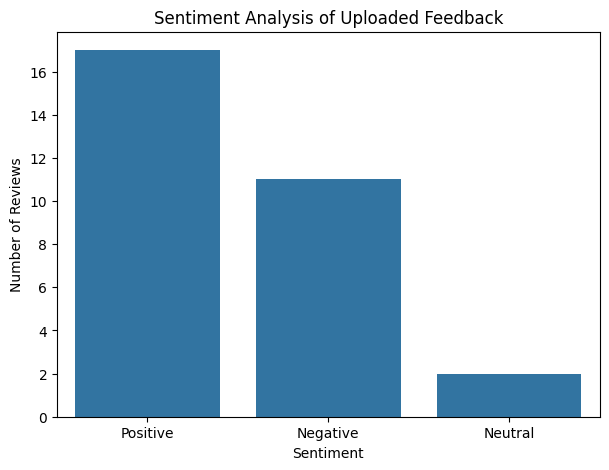

In [46]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=uploaded_df,
    x="predicted_sentiment"
)

plt.title("Sentiment Analysis of Uploaded Feedback")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

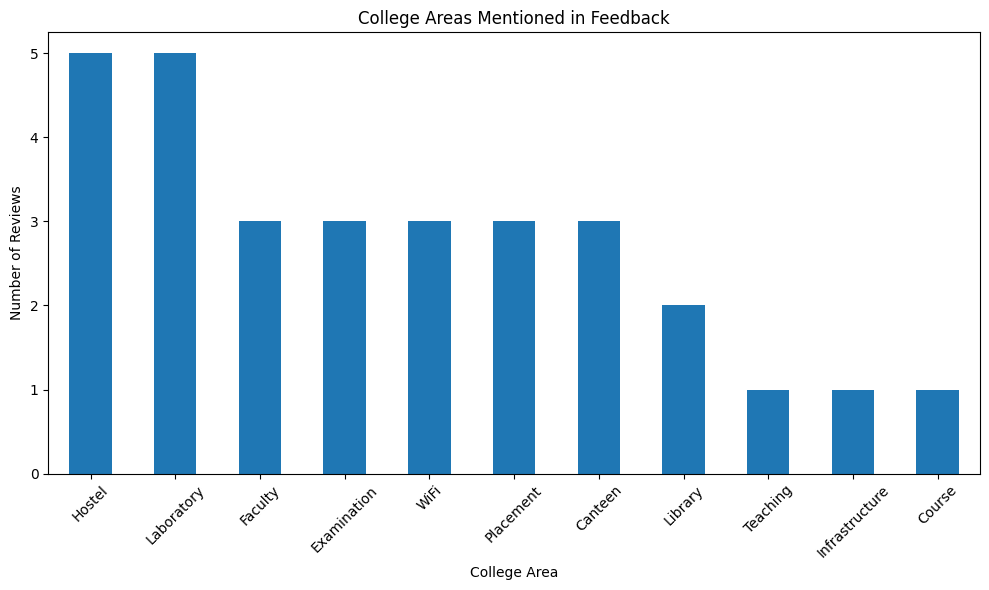

In [47]:
plt.figure(figsize=(10, 6))

uploaded_df["detected_aspect"].value_counts().plot(
    kind="bar"
)

plt.title("College Areas Mentioned in Feedback")
plt.xlabel("College Area")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [48]:
negative_areas = (
    uploaded_df[
        uploaded_df["predicted_sentiment"] == "Negative"
    ]["detected_aspect"]
    .value_counts()
)

print("===== AREAS WITH NEGATIVE FEEDBACK =====")
print(negative_areas)

===== AREAS WITH NEGATIVE FEEDBACK =====
detected_aspect
Laboratory     3
WiFi           2
Hostel         2
Examination    1
Placement      1
Canteen        1
Course         1
Name: count, dtype: int64


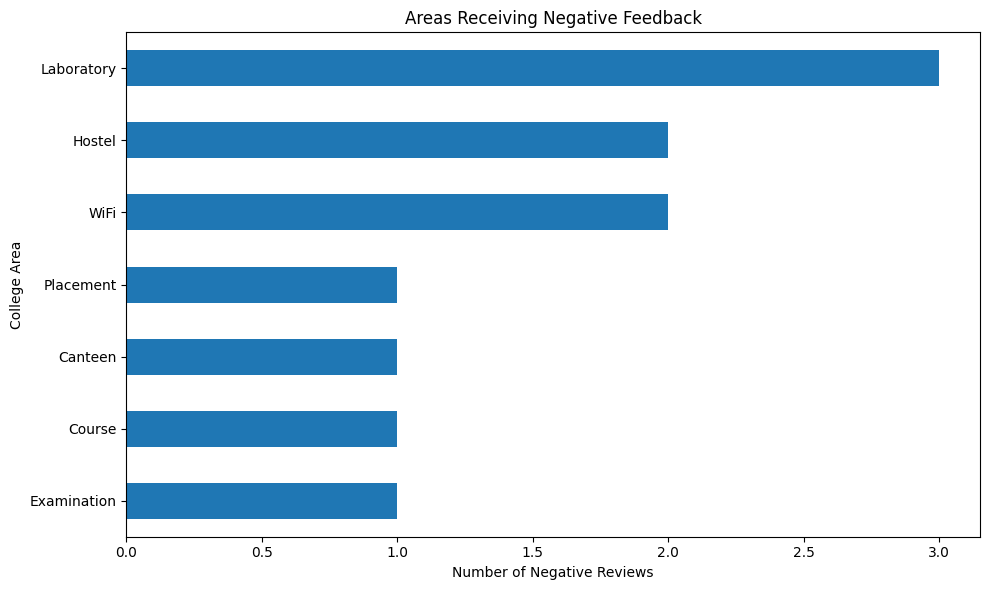

In [49]:
plt.figure(figsize=(10, 6))

negative_areas.sort_values().plot(
    kind="barh"
)

plt.title("Areas Receiving Negative Feedback")
plt.xlabel("Number of Negative Reviews")
plt.ylabel("College Area")

plt.tight_layout()
plt.show()

In [50]:
positive_count = (
    uploaded_df["predicted_sentiment"] == "Positive"
).sum()

negative_count = (
    uploaded_df["predicted_sentiment"] == "Negative"
).sum()

neutral_count = (
    uploaded_df["predicted_sentiment"] == "Neutral"
).sum()

print("========================================")
print("       AUTOMATIC FEEDBACK SUMMARY")
print("========================================")

print(f"\nTotal reviews analyzed: {total_reviews}")

print(f"Positive reviews: {positive_count}")
print(f"Negative reviews: {negative_count}")
print(f"Neutral reviews: {neutral_count}")

if len(negative_areas) > 0:

    print("\nAreas receiving negative feedback:")

    for aspect, count in negative_areas.head(5).items():
        print(f"- {aspect}: {count} reviews")

print("\nMost discussed college areas:")

top_aspects = (
    uploaded_df["detected_aspect"]
    .value_counts()
    .head(5)
)

for aspect, count in top_aspects.items():
    print(f"- {aspect}: {count} reviews")

       AUTOMATIC FEEDBACK SUMMARY

Total reviews analyzed: 30
Positive reviews: 17
Negative reviews: 11
Neutral reviews: 2

Areas receiving negative feedback:
- Laboratory: 3 reviews
- WiFi: 2 reviews
- Hostel: 2 reviews
- Examination: 1 reviews
- Placement: 1 reviews

Most discussed college areas:
- Hostel: 5 reviews
- Laboratory: 5 reviews
- Faculty: 3 reviews
- Examination: 3 reviews
- WiFi: 3 reviews


In [51]:
uploaded_df[
    [
        feedback_column,
        "predicted_sentiment",
        "detected_aspect"
    ]
].head(20)

,feedback,predicted_sentiment,detected_aspect
0,The faculty explains concepts very clearly and...,Positive,Faculty
1,The campus WiFi is extremely slow and disconne...,Negative,WiFi
2,The library has an excellent collection of books,Positive,Library
3,The hostel rooms are not clean and need better...,Negative,Hostel
4,The placement department provides good career ...,Positive,Placement
5,The canteen food is tasty and reasonably priced,Positive,Canteen
6,The laboratory computers are very slow,Negative,Laboratory
7,The classroom infrastructure is good and well ...,Positive,Hostel
8,The examination schedule is difficult to manage,Negative,Examination
9,The course syllabus is useful and well structured,Positive,Laboratory


In [52]:
output_file = "analyzed_college_feedback.csv"

uploaded_df.to_csv(
    output_file,
    index=False
)

print("Analysis report created successfully!")

Analysis report created successfully!


In [53]:
from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# -----------------------------------------
# BASIC STATISTICS
# -----------------------------------------

total_reviews = len(uploaded_df)

positive = (
    uploaded_df["predicted_sentiment"] == "Positive"
).sum()

negative = (
    uploaded_df["predicted_sentiment"] == "Negative"
).sum()

neutral = (
    uploaded_df["predicted_sentiment"] == "Neutral"
).sum()

positive_pct = round((positive / total_reviews) * 100, 1)
negative_pct = round((negative / total_reviews) * 100, 1)
neutral_pct = round((neutral / total_reviews) * 100, 1)


# -----------------------------------------
# DASHBOARD TITLE
# -----------------------------------------

display(HTML("""
<h1 style="text-align:center;">
🎓 College Feedback Intelligence Dashboard
</h1>

<p style="text-align:center;font-size:17px;">
NLP-Based Student Feedback Analysis
</p>
"""))


# -----------------------------------------
# KPI CARDS
# -----------------------------------------

display(HTML(f"""
<div style="
display:flex;
justify-content:space-around;
margin:25px 0;
">

<div style="
background:#e8f4ff;
padding:20px;
width:20%;
text-align:center;
border-radius:12px;
">
<h2>{total_reviews}</h2>
<p>Total Reviews</p>
</div>

<div style="
background:#e8f8ee;
padding:20px;
width:20%;
text-align:center;
border-radius:12px;
">
<h2>{positive_pct}%</h2>
<p>Positive</p>
</div>

<div style="
background:#ffecec;
padding:20px;
width:20%;
text-align:center;
border-radius:12px;
">
<h2>{negative_pct}%</h2>
<p>Negative</p>
</div>

<div style="
background:#fff8df;
padding:20px;
width:20%;
text-align:center;
border-radius:12px;
">
<h2>{neutral_pct}%</h2>
<p>Neutral</p>
</div>

</div>
"""))


# -----------------------------------------
# 1. OVERALL SENTIMENT
# -----------------------------------------

sentiment_counts = (
    uploaded_df["predicted_sentiment"]
    .value_counts()
    .reset_index()
)

sentiment_counts.columns = [
    "Sentiment",
    "Count"
]

fig1 = px.pie(
    sentiment_counts,
    names="Sentiment",
    values="Count",
    title="Overall Sentiment Distribution",
    hole=0.4
)

fig1.show()


# -----------------------------------------
# 2. SENTIMENT BY ASPECT
# -----------------------------------------

aspect_sentiment = pd.crosstab(
    uploaded_df["detected_aspect"],
    uploaded_df["predicted_sentiment"]
).reset_index()

fig2 = px.bar(
    aspect_sentiment,
    x="detected_aspect",
    y=["Positive", "Negative", "Neutral"],
    title="Sentiment Distribution Across College Aspects",
    barmode="group"
)

fig2.update_layout(
    xaxis_title="College Aspect",
    yaxis_title="Number of Reviews",
    xaxis_tickangle=-45
)

fig2.show()


# -----------------------------------------
# 3. ASPECT HEATMAP
# -----------------------------------------

heatmap_data = pd.crosstab(
    uploaded_df["detected_aspect"],
    uploaded_df["predicted_sentiment"]
)

fig3 = px.imshow(
    heatmap_data,
    text_auto=True,
    aspect="auto",
    title="Aspect vs Sentiment Heatmap"
)

fig3.update_layout(
    xaxis_title="Sentiment",
    yaxis_title="College Aspect"
)

fig3.show()


# -----------------------------------------
# 4. MOST DISCUSSED ASPECTS
# -----------------------------------------

aspect_counts = (
    uploaded_df["detected_aspect"]
    .value_counts()
    .reset_index()
)

aspect_counts.columns = [
    "Aspect",
    "Reviews"
]

fig4 = px.bar(
    aspect_counts,
    x="Reviews",
    y="Aspect",
    orientation="h",
    title="Most Discussed College Aspects"
)

fig4.show()


# -----------------------------------------
# 5. NEGATIVE FEEDBACK BY ASPECT
# -----------------------------------------

negative_aspects = (
    uploaded_df[
        uploaded_df["predicted_sentiment"] == "Negative"
    ]["detected_aspect"]
    .value_counts()
    .reset_index()
)

negative_aspects.columns = [
    "Aspect",
    "Negative Reviews"
]

fig5 = px.bar(
    negative_aspects,
    x="Negative Reviews",
    y="Aspect",
    orientation="h",
    title="🔴 Areas Receiving Negative Feedback"
)

fig5.show()


# -----------------------------------------
# 6. POSITIVE FEEDBACK BY ASPECT
# -----------------------------------------

positive_aspects = (
    uploaded_df[
        uploaded_df["predicted_sentiment"] == "Positive"
    ]["detected_aspect"]
    .value_counts()
    .reset_index()
)

positive_aspects.columns = [
    "Aspect",
    "Positive Reviews"
]

fig6 = px.bar(
    positive_aspects,
    x="Positive Reviews",
    y="Aspect",
    orientation="h",
    title="🟢 Areas Receiving Positive Feedback"
)

fig6.show()

In [55]:
aspect_summary = (
    pd.crosstab(
        uploaded_df["detected_aspect"],
        uploaded_df["predicted_sentiment"]
    )
)

# Make sure all sentiment columns exist
for col in ["Positive", "Negative", "Neutral"]:
    if col not in aspect_summary.columns:
        aspect_summary[col] = 0

aspect_summary["Total Reviews"] = (
    aspect_summary["Positive"]
    + aspect_summary["Negative"]
    + aspect_summary["Neutral"]
)

aspect_summary["Positive %"] = (
    aspect_summary["Positive"]
    / aspect_summary["Total Reviews"]
    * 100
).round(1)

aspect_summary["Negative %"] = (
    aspect_summary["Negative"]
    / aspect_summary["Total Reviews"]
    * 100
).round(1)

aspect_summary["Neutral %"] = (
    aspect_summary["Neutral"]
    / aspect_summary["Total Reviews"]
    * 100
).round(1)

aspect_summary = aspect_summary[
    [
        "Total Reviews",
        "Positive",
        "Negative",
        "Neutral",
        "Positive %",
        "Negative %",
        "Neutral %"
    ]
]

aspect_summary

predicted_sentiment,Total Reviews,Positive,Negative,Neutral,Positive %,Negative %,Neutral %
detected_aspect,,,,,,,
Canteen,3,1,1,1,33.3,33.3,33.3
Course,1,0,1,0,0.0,100.0,0.0
Examination,3,2,1,0,66.7,33.3,0.0
Faculty,3,3,0,0,100.0,0.0,0.0
Hostel,5,2,2,1,40.0,40.0,20.0
Infrastructure,1,1,0,0,100.0,0.0,0.0
Laboratory,5,2,3,0,40.0,60.0,0.0
Library,2,2,0,0,100.0,0.0,0.0
Placement,3,2,1,0,66.7,33.3,0.0


In [56]:
print("=" * 60)
print("       🎓 AUTOMATIC FEEDBACK INSIGHTS")
print("=" * 60)

# Most discussed aspect
most_discussed = (
    uploaded_df["detected_aspect"]
    .value_counts()
    .idxmax()
)

print(
    f"\n📌 Most discussed aspect: {most_discussed}"
)


# Aspect with most negative reviews
if len(negative_aspects) > 0:

    worst_aspect = negative_aspects.iloc[0]["Aspect"]
    worst_count = negative_aspects.iloc[0]["Negative Reviews"]

    print(
        f"🔴 Highest number of negative reviews: "
        f"{worst_aspect} ({worst_count})"
    )


# Aspect with most positive reviews
if len(positive_aspects) > 0:

    best_aspect = positive_aspects.iloc[0]["Aspect"]
    best_count = positive_aspects.iloc[0]["Positive Reviews"]

    print(
        f"🟢 Highest number of positive reviews: "
        f"{best_aspect} ({best_count})"
    )


print("\n📊 Overall Sentiment:")
print(f"Positive: {positive_pct}%")
print(f"Negative: {negative_pct}%")
print(f"Neutral: {neutral_pct}%")

       🎓 AUTOMATIC FEEDBACK INSIGHTS

📌 Most discussed aspect: Hostel
🔴 Highest number of negative reviews: Laboratory (3)
🟢 Highest number of positive reviews: Faculty (3)

📊 Overall Sentiment:
Positive: 56.7%
Negative: 36.7%
Neutral: 6.7%


In [57]:
!pip install -q gradio plotly openpyxl

In [58]:
# ============================================================
# COLLEGE FEEDBACK INTELLIGENCE SYSTEM - FRONTEND
# ============================================================

import gradio as gr
import pandas as pd
import plotly.express as px
from IPython.display import display, HTML


# ============================================================
# 1. FIND FEEDBACK COLUMN
# ============================================================

def find_feedback_column(df):

    possible_columns = [
        "feedback",
        "Feedback",
        "review",
        "Review",
        "comment",
        "Comment",
        "comments",
        "Comments"
    ]

    # Check common column names
    for column in possible_columns:
        if column in df.columns:
            return column

    # If no common name is found,
    # find the first text column
    for column in df.columns:
        if df[column].dtype == "object":
            return column

    return None


# ============================================================
# 2. ANALYZE UPLOADED FILE
# ============================================================

def analyze_file(file):

    # ---------- No file ----------
    if file is None:

        return (
            "## ⚠️ Please upload a CSV feedback file.",
            None,
            None,
            None,
            None,
            None,
            None,
            None
        )

    try:

        # ----------------------------------------------------
        # READ CSV
        # ----------------------------------------------------

        df_input = pd.read_csv(file)

        # ----------------------------------------------------
        # FIND FEEDBACK COLUMN
        # ----------------------------------------------------

        feedback_column = find_feedback_column(df_input)

        if feedback_column is None:

            return (
                "## ❌ Feedback column not found\n\n"
                f"Available columns: {list(df_input.columns)}",
                None,
                None,
                None,
                None,
                None,
                None,
                None
            )

        # ----------------------------------------------------
        # REMOVE EMPTY REVIEWS
        # ----------------------------------------------------

        df_input = df_input.dropna(
            subset=[feedback_column]
        ).copy()

        df_input[feedback_column] = (
            df_input[feedback_column]
            .astype(str)
        )

        # ----------------------------------------------------
        # TEXT PREPROCESSING
        # ----------------------------------------------------

        df_input["clean_feedback"] = (
            df_input[feedback_column]
            .apply(preprocess_text)
        )

        # ----------------------------------------------------
        # TF-IDF TRANSFORMATION
        # ----------------------------------------------------

        vectors = tfidf.transform(
            df_input["clean_feedback"]
        )

        # ----------------------------------------------------
        # SENTIMENT PREDICTION
        # ----------------------------------------------------

        df_input["Sentiment"] = model.predict(
            vectors
        )

        # ----------------------------------------------------
        # ASPECT DETECTION
        # ----------------------------------------------------

        df_input["Aspect"] = (
            df_input[feedback_column]
            .apply(detect_aspect)
        )

        # ====================================================
        # BASIC STATISTICS
        # ====================================================

        total = len(df_input)

        positive = (
            df_input["Sentiment"] == "Positive"
        ).sum()

        negative = (
            df_input["Sentiment"] == "Negative"
        ).sum()

        neutral = (
            df_input["Sentiment"] == "Neutral"
        ).sum()

        positive_pct = round(
            positive / total * 100, 1
        )

        negative_pct = round(
            negative / total * 100, 1
        )

        neutral_pct = round(
            neutral / total * 100, 1
        )

        # ====================================================
        # SENTIMENT DATA
        # ====================================================

        sentiment_data = (
            df_input["Sentiment"]
            .value_counts()
            .reindex(
                ["Positive", "Negative", "Neutral"],
                fill_value=0
            )
            .reset_index()
        )

        sentiment_data.columns = [
            "Sentiment",
            "Count"
        ]

        # ====================================================
        # 1. OVERALL SENTIMENT PIE CHART
        # ====================================================

        sentiment_fig = px.pie(
            sentiment_data,
            names="Sentiment",
            values="Count",
            hole=0.45,
            title="Overall Sentiment Distribution"
        )

        # ====================================================
        # 2. SENTIMENT BY ASPECT
        # ====================================================

        aspect_sentiment = pd.crosstab(
            df_input["Aspect"],
            df_input["Sentiment"]
        )

        for col in [
            "Positive",
            "Negative",
            "Neutral"
        ]:

            if col not in aspect_sentiment.columns:
                aspect_sentiment[col] = 0

        aspect_sentiment = (
            aspect_sentiment
            .reset_index()
        )

        aspect_fig = px.bar(
            aspect_sentiment,
            x="Aspect",
            y=[
                "Positive",
                "Negative",
                "Neutral"
            ],
            barmode="group",
            title="Sentiment Distribution Across College Aspects"
        )

        aspect_fig.update_layout(
            xaxis_title="College Aspect",
            yaxis_title="Number of Reviews",
            xaxis_tickangle=-45
        )

        # ====================================================
        # 3. ASPECT VS SENTIMENT HEATMAP
        # ====================================================

        heatmap_data = pd.crosstab(
            df_input["Aspect"],
            df_input["Sentiment"]
        )

        heatmap_data = heatmap_data.reindex(
            columns=[
                "Positive",
                "Negative",
                "Neutral"
            ],
            fill_value=0
        )

        heatmap_fig = px.imshow(
            heatmap_data,
            text_auto=True,
            aspect="auto",
            title="Aspect vs Sentiment Heatmap"
        )

        heatmap_fig.update_layout(
            xaxis_title="Sentiment",
            yaxis_title="College Aspect"
        )

        # ====================================================
        # 4. NEGATIVE FEEDBACK BY ASPECT
        # ====================================================

        negative_aspects = (
            df_input[
                df_input["Sentiment"] == "Negative"
            ]["Aspect"]
            .value_counts()
            .reset_index()
        )

        negative_aspects.columns = [
            "Aspect",
            "Negative Reviews"
        ]

        if len(negative_aspects) > 0:

            negative_fig = px.bar(
                negative_aspects,
                x="Negative Reviews",
                y="Aspect",
                orientation="h",
                title="🔴 Areas Receiving Negative Feedback"
            )

        else:

            negative_fig = px.bar(
                title="No Negative Feedback Found"
            )

        # ====================================================
        # 5. POSITIVE FEEDBACK BY ASPECT
        # ====================================================

        positive_aspects = (
            df_input[
                df_input["Sentiment"] == "Positive"
            ]["Aspect"]
            .value_counts()
            .reset_index()
        )

        positive_aspects.columns = [
            "Aspect",
            "Positive Reviews"
        ]

        if len(positive_aspects) > 0:

            positive_fig = px.bar(
                positive_aspects,
                x="Positive Reviews",
                y="Aspect",
                orientation="h",
                title="🟢 Areas Receiving Positive Feedback"
            )

        else:

            positive_fig = px.bar(
                title="No Positive Feedback Found"
            )

        # ====================================================
        # 6. AUTOMATIC INSIGHTS
        # ====================================================

        most_discussed = (
            df_input["Aspect"]
            .value_counts()
            .idxmax()
        )

        # Highest negative aspect
        if len(negative_aspects) > 0:

            highest_negative = (
                negative_aspects.iloc[0]["Aspect"]
            )

            highest_negative_count = int(
                negative_aspects.iloc[0]["Negative Reviews"]
            )

        else:

            highest_negative = "None"
            highest_negative_count = 0

        # Highest positive aspect
        if len(positive_aspects) > 0:

            highest_positive = (
                positive_aspects.iloc[0]["Aspect"]
            )

            highest_positive_count = int(
                positive_aspects.iloc[0]["Positive Reviews"]
            )

        else:

            highest_positive = "None"
            highest_positive_count = 0

        # ====================================================
        # INSIGHTS TEXT
        # ====================================================

        insights = f"""
# 🎓 College Feedback Intelligence Report

## 📊 Overall Results

| Metric | Result |
|---|---:|
| **Total Reviews** | **{total}** |
| 🟢 Positive | **{positive_pct}%** |
| 🔴 Negative | **{negative_pct}%** |
| 🟡 Neutral | **{neutral_pct}%** |

---

## 🔎 Key Insights

### 📌 Most Discussed Area
**{most_discussed}**

### 🔴 Area Receiving Most Negative Feedback
**{highest_negative}** — {highest_negative_count} reviews

### 🟢 Area Receiving Most Positive Feedback
**{highest_positive}** — {highest_positive_count} reviews

---

### 🤖 NLP Pipeline

The uploaded feedback was processed using:

**Text Preprocessing → TF-IDF → Logistic Regression → Sentiment Prediction → Aspect Detection**
"""

        # ====================================================
        # PREPARE REPORT
        # ====================================================

        report_df = df_input.drop(
            columns=["clean_feedback"]
        )

        report_path = "/content/analyzed_feedback_report.csv"

        report_df.to_csv(
            report_path,
            index=False
        )

        # ====================================================
        # DISPLAY TABLE
        # ====================================================

        display_df = report_df[
            [
                feedback_column,
                "Sentiment",
                "Aspect"
            ]
        ]

        # ====================================================
        # RETURN ALL RESULTS
        # ====================================================

        return (
            insights,
            sentiment_fig,
            aspect_fig,
            heatmap_fig,
            negative_fig,
            positive_fig,
            display_df,
            report_path
        )

    except Exception as e:

        return (
            f"""
            ## ❌ Error while analyzing the file

            **Error:** `{str(e)}`

            Please check that your CSV contains a feedback/review
            column and try again.
            """,
            None,
            None,
            None,
            None,
            None,
            None,
            None
        )


# ============================================================
# 3. FRONTEND CSS
# ============================================================

custom_css = """
#main-title {
    text-align: center;
    font-size: 36px;
    font-weight: bold;
}

#subtitle {
    text-align: center;
    font-size: 18px;
    margin-bottom: 20px;
}

.gradio-container {
    max-width: 1400px !important;
}
"""


# ============================================================
# 4. CREATE GRADIO APPLICATION
# ============================================================

with gr.Blocks(
    theme=gr.themes.Soft(),
    css=custom_css,
    title="College Feedback Intelligence"
) as app:

    # --------------------------------------------------------
    # HEADER
    # --------------------------------------------------------

    gr.Markdown(
        """
        <div id="main-title">
        🎓 College Feedback Intelligence System
        </div>

        <div id="subtitle">
        NLP-Based Student Feedback Analysis Dashboard
        </div>
        """
    )

    gr.Markdown(
        """
        ### 📁 Upload Student Feedback

        Upload a **CSV file containing student feedback**.
        The system will automatically analyze sentiment,
        identify college aspects, generate visual insights,
        and create a downloadable report.
        """
    )

    # --------------------------------------------------------
    # UPLOAD SECTION
    # --------------------------------------------------------

    with gr.Row():

        file_input = gr.File(
            label="📁 Upload Feedback CSV",
            file_types=[".csv"],
            type="filepath"
        )

        analyze_button = gr.Button(
            "🔍 Analyze Feedback",
            variant="primary"
        )

    # --------------------------------------------------------
    # INSIGHTS
    # --------------------------------------------------------

    gr.Markdown("---")

    insights_output = gr.Markdown()

    # --------------------------------------------------------
    # CHARTS
    # --------------------------------------------------------

    gr.Markdown(
        "## 📊 Visual Analytics"
    )

    with gr.Row():

        sentiment_output = gr.Plot(
            label="Overall Sentiment"
        )

        aspect_output = gr.Plot(
            label="Sentiment by Aspect"
        )

    with gr.Row():

        heatmap_output = gr.Plot(
            label="Aspect vs Sentiment"
        )

    with gr.Row():

        negative_output = gr.Plot(
            label="Negative Feedback"
        )

        positive_output = gr.Plot(
            label="Positive Feedback"
        )

    # --------------------------------------------------------
    # TABLE
    # --------------------------------------------------------

    gr.Markdown("---")

    gr.Markdown(
        "## 📋 Detailed Feedback Analysis"
    )

    table_output = gr.Dataframe(
        label="Analyzed Student Feedback",
        interactive=False
    )

    # --------------------------------------------------------
    # DOWNLOAD
    # --------------------------------------------------------

    gr.Markdown("---")

    gr.Markdown(
        "## ⬇️ Download Report"
    )

    download_output = gr.File(
        label="Download Analyzed Feedback Report"
    )

    # --------------------------------------------------------
    # BUTTON ACTION
    # --------------------------------------------------------

    analyze_button.click(
        fn=analyze_file,
        inputs=file_input,
        outputs=[
            insights_output,
            sentiment_output,
            aspect_output,
            heatmap_output,
            negative_output,
            positive_output,
            table_output,
            download_output
        ]
    )


# ============================================================
# 5. LAUNCH
# ============================================================

app.launch(
    share=True
)

/tmp/ipykernel_7314/776582679.py:505: UserWarning:

The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://636464f5280c985e06.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [59]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model files saved successfully!")

Model files saved successfully!


In [60]:
from google.colab import files

files.download("sentiment_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
import sklearn
print(sklearn.__version__)

1.6.1
